Préparation des données

In [30]:
import pandas as pd

train = pd.read_csv("../data/raw/train(2).csv")
valid = pd.read_csv("../data/raw/validation.csv")

TARGET = "Label"

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_valid = valid.drop(columns=[TARGET])
y_valid = valid[TARGET]

cat_features = ["proto", "service", "state"]

print("Train :", X_train.shape)
print("Valid :", X_valid.shape)

Train : (180371, 42)
Valid : (38651, 42)


Entraînement du CatBoost Baseline

In [31]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [32]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=500,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 0.7228726	test: 0.7223011	best: 0.7223011 (0)	total: 5.2s	remaining: 43m 13s


KeyboardInterrupt: 

Prediction

In [ ]:
y_pred = model.predict(X_valid)

y_pred = y_pred.flatten()

Macro F1

In [ ]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_valid,
    y_pred,
    average="macro"
)

print("Macro F1 :", macro_f1)

Macro F1 : 0.5357730057688277


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_valid,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9000    0.9455    0.9222     13950
           1     0.9982    0.9788    0.9884      8831
           2     0.6239    0.8980    0.7363      6679
           3     0.6976    0.5422    0.6101      3637
           4     0.4064    0.1353    0.2031      2453
           5     0.8940    0.7755    0.8305      2098
           6     0.8462    0.0274    0.0530       402
           7     0.7941    0.0774    0.1410       349
           8     0.6359    0.5796    0.6065       226
           9     1.0000    0.1538    0.2667        26

    accuracy                         0.8263     38651
   macro avg     0.7796    0.5114    0.5358     38651
weighted avg     0.8210    0.8263    0.8068     38651



Matrice de confusion

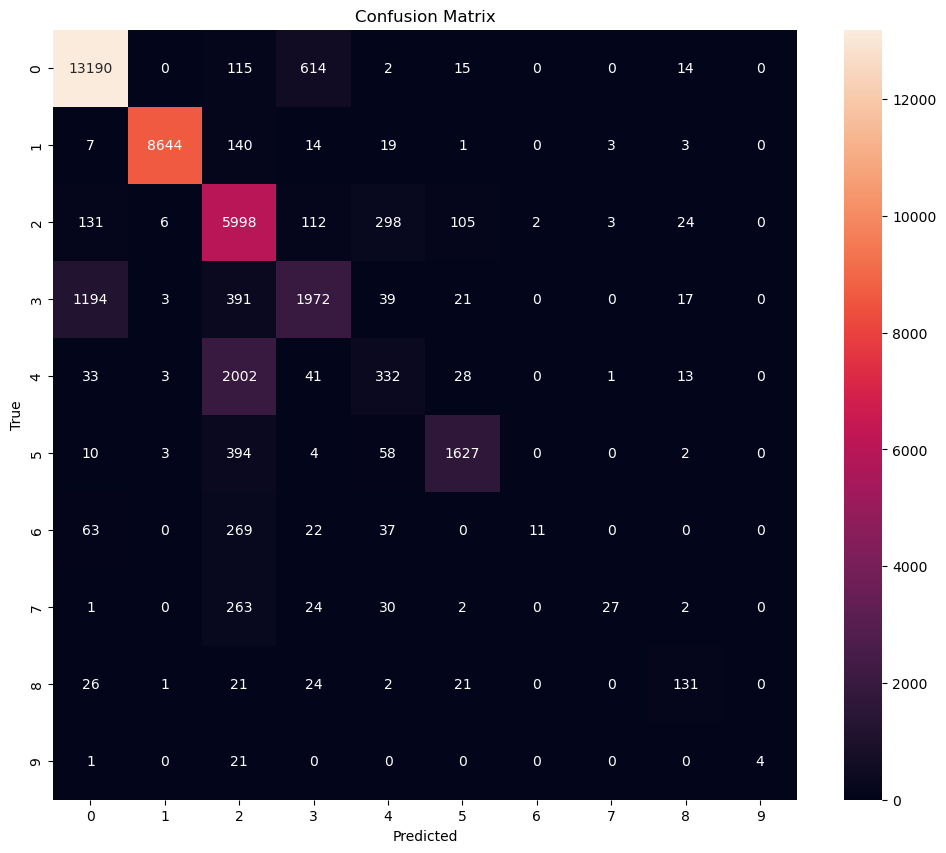

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_valid,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

Importance des variables

In [ ]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.get_feature_importance()
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance.head(20))

             feature  importance
26             smean   12.975050
6             sbytes   12.930963
9               sttl   12.384773
2            service    8.475349
1              proto    7.510222
35    ct_dst_src_ltm    5.838004
40        ct_srv_dst    5.631795
34  ct_dst_sport_ltm    4.748831
7             dbytes    4.346494
27             dmean    3.297481
30        ct_srv_src    2.513752
33  ct_src_dport_ltm    1.551697
10              dttl    1.471213
12             dload    1.111959
14             dloss    1.095570
0                dur    1.024271
3              state    1.001726
39        ct_src_ltm    0.988274
19              swin    0.884823
24            synack    0.833582


Analyse des erreurs

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, y_pred)

print(cm)

[[13190     0   115   614     2    15     0     0    14     0]
 [    7  8644   140    14    19     1     0     3     3     0]
 [  131     6  5998   112   298   105     2     3    24     0]
 [ 1194     3   391  1972    39    21     0     0    17     0]
 [   33     3  2002    41   332    28     0     1    13     0]
 [   10     3   394     4    58  1627     0     0     2     0]
 [   63     0   269    22    37     0    11     0     0     0]
 [    1     0   263    24    30     2     0    27     2     0]
 [   26     1    21    24     2    21     0     0   131     0]
 [    1     0    21     0     0     0     0     0     0     4]]


ANALYSE DES TROIS EN MEME TEMPS 

In [ ]:
analysis_df = valid.copy()

analysis_df["pred"] = y_pred

for cls, name in {
    6: "Analysis",
    7: "Backdoor",
    9: "Worms"
}.items():

    print("\n" + "="*60)
    print(f"{name} (Classe {cls})")
    print("="*60)

    print(
        analysis_df[
            analysis_df["Label"] == cls
        ]["pred"]
        .value_counts()
        .sort_index()
    )


Analysis (Classe 6)
pred
0     63
2    269
3     22
4     37
6     11
Name: count, dtype: int64

Backdoor (Classe 7)
pred
0      1
2    263
3     24
4     30
5      2
7     27
8      2
Name: count, dtype: int64

Worms (Classe 9)
pred
0     1
2    21
9     4
Name: count, dtype: int64


calculer les poids 

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.27706758832565287), np.int64(1): np.float64(0.43769807566308333), np.int64(2): np.float64(0.5787242917188051), np.int64(3): np.float64(1.062756304501532), np.int64(4): np.float64(1.575705425002184), np.int64(5): np.float64(1.8422122357266877), np.int64(6): np.float64(9.624919957310565), np.int64(7): np.float64(11.058920907418761), np.int64(8): np.float64(17.048298676748583), np.int64(9): np.float64(147.8450819672131)}


CatBoost V2

In [ ]:
model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    class_weights=class_weights,
    random_seed=42,
    verbose=100
)

entrainement 

In [ ]:
model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=300,
    depth=6,
    learning_rate=0.05,
    class_weights=class_weights,
    random_seed=42,
    verbose=50,
    thread_count=-1
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 2.1607044	test: 2.1590524	best: 2.1590524 (0)	total: 6.3s	remaining: 31m 24s
50:	learn: 0.9870509	test: 0.9925515	best: 0.9925515 (50)	total: 4m 52s	remaining: 23m 48s
100:	learn: 0.8510733	test: 0.8623403	best: 0.8623403 (100)	total: 9m 16s	remaining: 18m 15s
150:	learn: 0.8045544	test: 0.8199271	best: 0.8199271 (150)	total: 13m 14s	remaining: 13m 4s
200:	learn: 0.7806632	test: 0.7994743	best: 0.7994743 (200)	total: 17m 20s	remaining: 8m 32s
250:	learn: 0.7561872	test: 0.7797197	best: 0.7797197 (250)	total: 21m 7s	remaining: 4m 7s
299:	learn: 0.7374136	test: 0.7662292	best: 0.7662292 (299)	total: 25m 5s	remaining: 0us

bestTest = 0.7662291805
bestIteration = 299



CatBoostClassifier(class_weights={np.int64(0): np.float64(0.27706758832565287), np.int64(1): np.float64(0.43769807566308333), np.int64(2): np.float64(0.5787242917188051), np.int64(3): np.float64(1.062756304501532), np.int64(4): np.float64(1.575705425002184), np.int64(5): np.float64(1.8422122357266877), np.int64(6): np.float64(9.624919957310565), np.int64(7): np.float64(11.058920907418761), np.int64(8): np.float64(17.048298676748583), np.int64(9): np.float64(147.8450819672131)}, depth=6, eval_metric='MultiClass', iterations=300, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=50)

Predictions 

In [ ]:
y_pred_v2 = model.predict(X_valid)
y_pred_v2 = y_pred_v2.flatten()

Macro F1 v2

In [ ]:
from sklearn.metrics import f1_score

macro_f1_v2 = f1_score(
    y_valid,
    y_pred_v2,
    average="macro"
)

print("Macro F1 V2 :", macro_f1_v2)

Macro F1 V2 : 0.49772189901832187


Rapport complet 

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_valid,
        y_pred_v2,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9979    0.7128    0.8316     13950
           1     0.9986    0.9746    0.9865      8831
           2     0.8530    0.4534    0.5920      6679
           3     0.4517    0.7941    0.5759      3637
           4     0.3516    0.4806    0.4061      2453
           5     0.8224    0.8165    0.8194      2098
           6     0.0870    0.3109    0.1360       402
           7     0.0819    0.4499    0.1386       349
           8     0.2406    0.9381    0.3830       226
           9     0.0571    1.0000    0.1081        26

    accuracy                         0.7213     38651
   macro avg     0.4942    0.6931    0.4977     38651
weighted avg     0.8483    0.7213    0.7572     38651



F1 worms v2 

In [ ]:
report = classification_report(
    y_valid,
    y_pred_v2,
    output_dict=True
)

print("F1 Worms :", report["9"]["f1-score"])

F1 Worms : 0.10810810810810811


Matrice de confusion 

In [ ]:
from sklearn.metrics import confusion_matrix

cm_v2 = confusion_matrix(
    y_valid,
    y_pred_v2
)

print(cm_v2)

[[9943    0   90 3210   14   20  434    2  221   16]
 [   3 8607  102   26   49    1    4   13   14   12]
 [  12    8 3028  213 1468  298  435  758  147  312]
 [   4    0   43 2888  152   19   61  220  230   20]
 [   2    4  275   42 1179   29  295  553   34   40]
 [   0    0    1    3  193 1713   46  100   18   24]
 [   0    0    3    0  160    0  125  114    0    0]
 [   0    0    8    1  138    1   36  157    5    3]
 [   0    0    0   10    0    2    0    0  212    2]
 [   0    0    0    0    0    0    0    0    0   26]]


In [ ]:
# Ensure `manual_weights` is defined; default to computed `class_weights` if absent
try:
    manual_weights
except NameError:
    manual_weights = class_weights
    print("`manual_weights` not found — using computed `class_weights` as manual_weights.")
else:
    print("`manual_weights` already defined.")

Creation du modele v3 

In [38]:
manual_weights = {
    0: 1.0,
    1: 1.0,
    2: 1.0,
    3: 1.5,
    4: 2.0,
    5: 2.0,
    6: 4.0,
    7: 4.0,
    8: 5.0,
    9: 8.0
}

In [39]:
print(manual_weights)

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.5, 4: 2.0, 5: 2.0, 6: 4.0, 7: 4.0, 8: 5.0, 9: 8.0}


In [43]:
model_v3 = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=200,
    depth=6,
    learning_rate=0.1,
    class_weights=manual_weights,
    random_seed=42,
    thread_count=-1,
    verbose=50
)

In [44]:
print(X_train.shape)
print(X_valid.shape)
print(cat_features)
print(manual_weights)

(180371, 42)
(38651, 42)
['proto', 'service', 'state']
{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.5, 4: 2.0, 5: 2.0, 6: 4.0, 7: 4.0, 8: 5.0, 9: 8.0}


In [45]:
model_v3.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 1.8459988	test: 1.8470757	best: 1.8470757 (0)	total: 5.17s	remaining: 17m 7s
50:	learn: 0.6735363	test: 0.6813788	best: 0.6813788 (50)	total: 4m 49s	remaining: 14m 5s
100:	learn: 0.6250180	test: 0.6360728	best: 0.6360728 (100)	total: 9m 38s	remaining: 9m 27s
150:	learn: 0.6001172	test: 0.6152522	best: 0.6152522 (150)	total: 14m 7s	remaining: 4m 35s
199:	learn: 0.5853176	test: 0.6039206	best: 0.6039206 (199)	total: 18m 31s	remaining: 0us

bestTest = 0.6039205963
bestIteration = 199



CatBoostClassifier(class_weights={0: 1.0, 1: 1.0, 2: 1.0, 3: 1.5, 4: 2.0, 5: 2.0, 6: 4.0, 7: 4.0, 8: 5.0, 9: 8.0}, depth=6, eval_metric='MultiClass', iterations=200, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=50)

predictions 

In [46]:
y_pred_v3 = model_v3.predict(X_valid)

y_pred_v3 = y_pred_v3.flatten()

Macro F1

In [47]:
from sklearn.metrics import f1_score

macro_f1_v3 = f1_score(
    y_valid,
    y_pred_v3,
    average="macro"
)

print("Macro F1 V3 :", macro_f1_v3)

Macro F1 V3 : 0.611493266901091


Classification reports 

In [48]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_valid,
        y_pred_v3,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9311    0.8896    0.9099     13950
           1     0.9997    0.9753    0.9873      8831
           2     0.8303    0.5369    0.6521      6679
           3     0.6191    0.6555    0.6368      3637
           4     0.3493    0.7892    0.4842      2453
           5     0.8445    0.8103    0.8270      2098
           6     0.2251    0.1517    0.1813       402
           7     0.2287    0.1691    0.1944       349
           8     0.4098    0.7743    0.5360       226
           9     0.7200    0.6923    0.7059        26

    accuracy                         0.8005     38651
   macro avg     0.6158    0.6444    0.6115     38651
weighted avg     0.8415    0.8005    0.8095     38651



F1 worms

In [49]:
report_v3 = classification_report(
    y_valid,
    y_pred_v3,
    output_dict=True
)

print("F1 Worms :", report_v3["9"]["f1-score"])

F1 Worms : 0.7058823529411765


Matrice de confusion 

In [50]:
from sklearn.metrics import confusion_matrix

cm_v3 = confusion_matrix(
    y_valid,
    y_pred_v3
)

print(cm_v3)

[[12410     0   134  1251     5    15    55     0    80     0]
 [    6  8613   121    21    57     3     0     3     5     2]
 [  118     1  3586   138  2394   239    53    76    70     4]
 [  711     1    52  2384   306    15    44    64    59     1]
 [   28     1   347    27  1936    31    29    30    24     0]
 [    4     0    44     6   332  1700     1     0    11     0]
 [   40     0     5     0   270     0    61    26     0     0]
 [    1     0    14     0   243     1    28    59     3     0]
 [   10     0     8    24     0     9     0     0   175     0]
 [    0     0     8     0     0     0     0     0     0    18]]


Heatmap

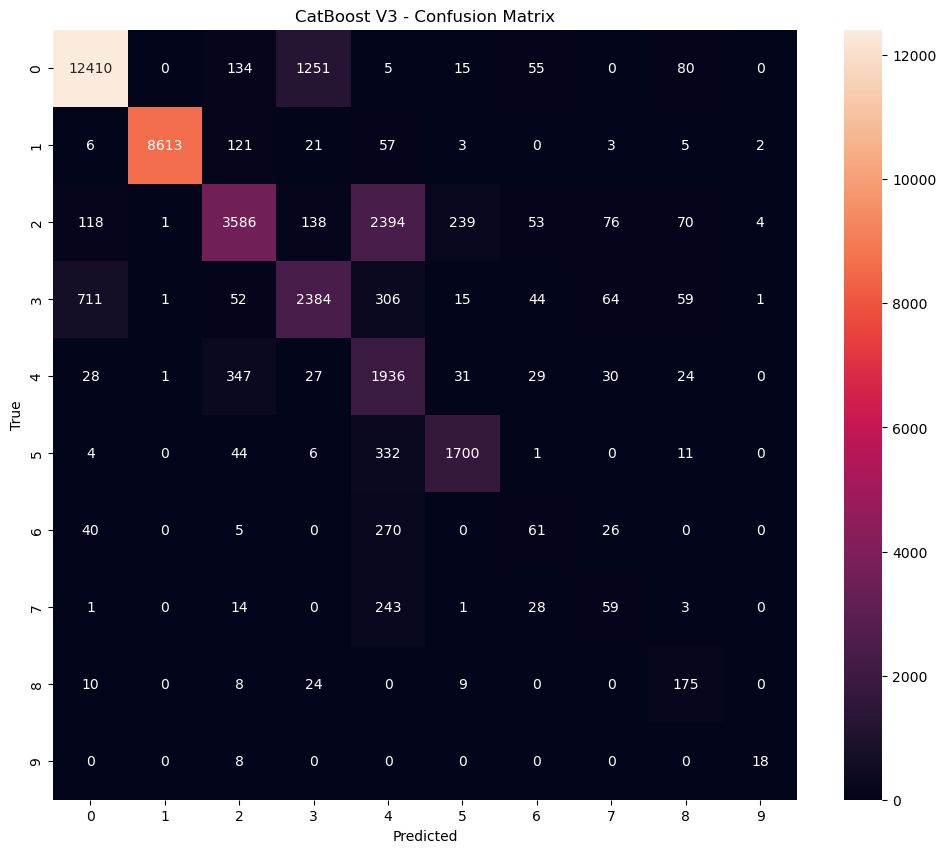

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_v3,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CatBoost V3 - Confusion Matrix")

plt.show()

Importance des variables 

In [52]:
import pandas as pd

importance_v3 = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_v3.get_feature_importance()
})

importance_v3 = importance_v3.sort_values(
    "importance",
    ascending=False
)

print(importance_v3.head(20))

             feature  importance
6             sbytes   18.679844
9               sttl   12.406273
26             smean   11.687568
2            service    9.679583
1              proto    7.144900
40        ct_srv_dst    6.345253
35    ct_dst_src_ltm    5.146271
27             dmean    3.249451
7             dbytes    3.199899
30        ct_srv_src    2.138888
34  ct_dst_sport_ltm    1.675081
33  ct_src_dport_ltm    1.649937
3              state    1.305088
14             dloss    1.192429
31      ct_state_ttl    1.081770
5              dpkts    1.057176
24            synack    1.041175
12             dload    1.003367
10              dttl    1.002982
13             sloss    0.987704


sauvegarde des scores 

In [53]:
results.append({
    "model": "CatBoost V3",
    "macro_f1": macro_f1_v3,
    "worms_f1": report_v3["9"]["f1-score"]
})

pd.DataFrame(results)

NameError: name 'results' is not defined